In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
class LinearRegression:
    def __init__(self, epochs = 100, batch_size = 1, lr = 1e-05, shuffle = False):
        # Số lần học của mô hình
        self.epochs = epochs
        # Tốc độ học của mô hình
        self.lr = lr
        # batch_size - lô - số sample lấy ra huấn luyện và cập nhật trọng số của mô hinh
        self.batch_size = batch_size
        # tham số shuffle cho phép xáo trộn dữ liệu ở mỗi epoch
        self.shuffle = shuffle
        # trọng số w của mô hình
        self.w = None
        # List lưu Loss của các epoch
        self.Losses = []
        
    # Hàm huấn luyện của mô hình
    def predict(self,X):
        if X.ndim ==1:
            raise ValueError("X must be 2-Dimension")
        if X.shape[1] == self.n_features:
            feature_add = np.ones(X.shape[0]).reshape(-1,1)
            X = np.concatenate([feature_add,X],axis=1)    
        return X@self.w
            
    # Hàm tính loss của mô hình
    def compute_Loss(self,y_pred,y):
        return np.mean((y_pred-y)**2)

    # Hàm tính đạo hàm của Loss theo trọng số w
    def dL_dw(self,X,y_pred,y):
        return X.T@(y_pred-y)*(2/X.shape[0])
        
    # Hàm huấn luyện của mô hình
    def fit(self,X,y):
        if X.ndim  == 1: raise ValueError("X must be 2-Dimension")
        else:
            # lấy số sample và số đặc trưng của bộ dữ liệu huấn luyện
            self.n_samples, self.n_features =X.shape[0], X.shape[1]
            
            # random bộ trọng số w cho mô hình
            self.w = np.random.uniform(-1,1,size=self.n_features+1)

            # Đặc trưng 1 thêm vào đầu mỗi sample
            feature_add = np.ones(X.shape[0]).reshape(-1,1)
            # dữ liệu train
            data_train = np.concatenate([feature_add,X,y.reshape(-1,1)],axis=1)
            if self.shuffle: np.random.shuffle(data_train)
            for epoch in range(self.epochs):
                Loss =[]
                for i in range(0,data_train.shape[0],self.batch_size):
                    batch = data_train[i:i+self.batch_size]
                    X_train, y_train = batch[:,:-1],batch[:,-1]
                    # Nếu batch_size = 1 -> reshape (-1, n_features+1)
                    if X_train.ndim == 1: X_train = X_train.reshape(-1,self.n_features+1)
                    y_pred = self.predict(X_train)
                    # Tính loss của lần học hiện tại
                    Loss.append(self.compute_Loss(y_pred,y_train))
                    # tính đạo của của Loss theo trọng số w
                    dL_dw = self.dL_dw(X_train,y_pred,y_train)

                    # Cập nhật trọng số của mô hình
                    self.w -= self.lr*dL_dw
                Loss = sum(Loss)/len(Loss)
                self.Losses.append(Loss)
                print(f"epoch:{epoch+1:<5}=============== loss = {Loss:<18} =================== w= {str(self.w):<40}")

In [3]:
FILE_PATH = 'advertising.csv'

# ĐỌC BẢNG DỮ LIỆU LÊN

In [4]:
df = pd.read_csv(FILE_PATH)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


# LẤY RA CÁC THÔNG TIN CƠ BẢN CỦA BỘ DỮ LIỆU

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# LẤY CÁC ĐẶC TRƯNG VÀ NHÃN CỦA DL RA

In [7]:
X, y = df.iloc[:,:-1],df.iloc[:,-1]

In [8]:
# chuẩn hóa các đặc trưng của bộ dữ liệu
Scaler = MinMaxScaler()
X = Scaler.fit_transform(X)
X[:5]

array([[0.77578627, 0.76209677, 0.60598065],
       [0.1481231 , 0.79233871, 0.39401935],
       [0.0557998 , 0.92540323, 0.60686016],
       [0.50997633, 0.83266129, 0.51187335],
       [0.60906324, 0.21774194, 0.51099384]])

In [9]:
y = y.to_numpy()

# CHIA DỮ LIỆU TRAIN TEST

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# KHỞI TẠO MÔ HÌNH VÀ HUẤN LUYỆN

In [22]:
rg = LinearRegression(lr = 0.01,epochs = 400,shuffle=True)

In [23]:
rg.fit(X_train,y_train)

epoch:1    =============== loss = 34.00658682645524  =================== w= [9.41399494 6.97606678 4.73437863 2.94495713]
epoch:2    =============== loss = 8.651244403100417  =================== w= [8.67108446 8.7637747  4.54753703 2.62137231]
epoch:3    =============== loss = 6.633260673096538  =================== w= [ 8.00141641 10.17419014  4.4294351   2.34894712]
epoch:4    =============== loss = 5.314067928336749  =================== w= [ 7.44258057 11.30753522  4.37615802  2.12727119]
epoch:5    =============== loss = 4.450943843541812  =================== w= [ 6.97700093 12.21969359  4.36646714  1.94532549]
epoch:6    =============== loss = 3.8833365943716536 =================== w= [ 6.58953242 12.95487805  4.38505099  1.79458721]
epoch:7    =============== loss = 3.5082689778895193 =================== w= [ 6.26740272 13.54823703  4.42106211  1.66850119]
epoch:8    =============== loss = 3.2593135003494957 =================== w= [ 5.99986233 14.02776052  4.46691645  1.56201478]


epoch:177  =============== loss = 2.7476110041736286 =================== w= [ 4.74697036 16.10170521  5.08148095  0.68205446]
epoch:178  =============== loss = 2.747611003621464  =================== w= [ 4.74697037 16.1017052   5.08148097  0.68205438]
epoch:179  =============== loss = 2.747611003111634  =================== w= [ 4.74697038 16.1017052   5.08148099  0.68205431]
epoch:180  =============== loss = 2.747611002640894  =================== w= [ 4.74697039 16.1017052   5.08148101  0.68205424]
epoch:181  =============== loss = 2.7476110022062445 =================== w= [ 4.7469704  16.1017052   5.08148103  0.68205418]
epoch:182  =============== loss = 2.747611001804919  =================== w= [ 4.74697041 16.10170519  5.08148105  0.68205412]
epoch:183  =============== loss = 2.7476110014343638 =================== w= [ 4.74697042 16.10170519  5.08148106  0.68205407]
epoch:184  =============== loss = 2.7476110010922183 =================== w= [ 4.74697042 16.10170519  5.08148108  0.68

epoch:343  =============== loss = 2.7476109969717095 =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:344  =============== loss = 2.7476109969717095 =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:345  =============== loss = 2.7476109969717073 =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:346  =============== loss = 2.747610996971707  =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:347  =============== loss = 2.747610996971707  =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:348  =============== loss = 2.7476109969717055 =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:349  =============== loss = 2.7476109969717046 =================== w= [ 4.74697051 16.10170517  5.08148125  0.68205342]
epoch:350  =============== loss = 2.7476109969717055 =================== w= [ 4.74697051 16.10170517  5.08148125  0.68

In [24]:
y_pred = rg.predict(X_test)

In [25]:
print(f"Loss của mô hình: {mean_squared_error(y_pred,y_test)}")

Loss của mô hình: 2.9794639330567847


# VẼ LOSS CỦA MÔ HÌNH SAU KHI HUẤN LUYỆN

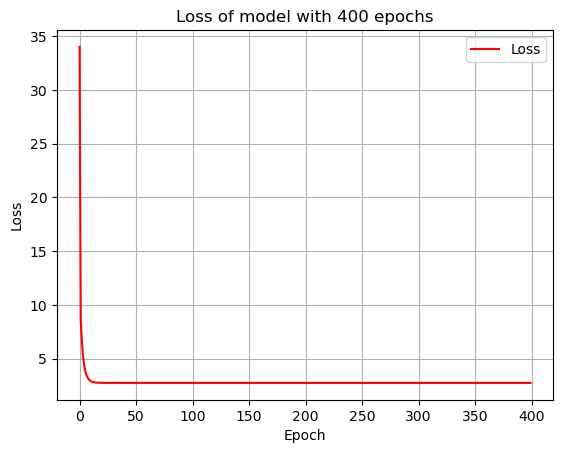

In [26]:
plt.title(f"Loss of model with {rg.epochs} epochs")
plt.plot(rg.Losses,'r',label = 'Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()